Liczba znalezionych frame'ów: 201
Wyświetlam pierwszy frame...


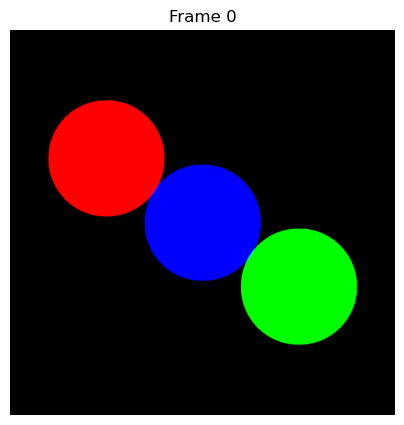

Wyświetlam frame'y co 10%:


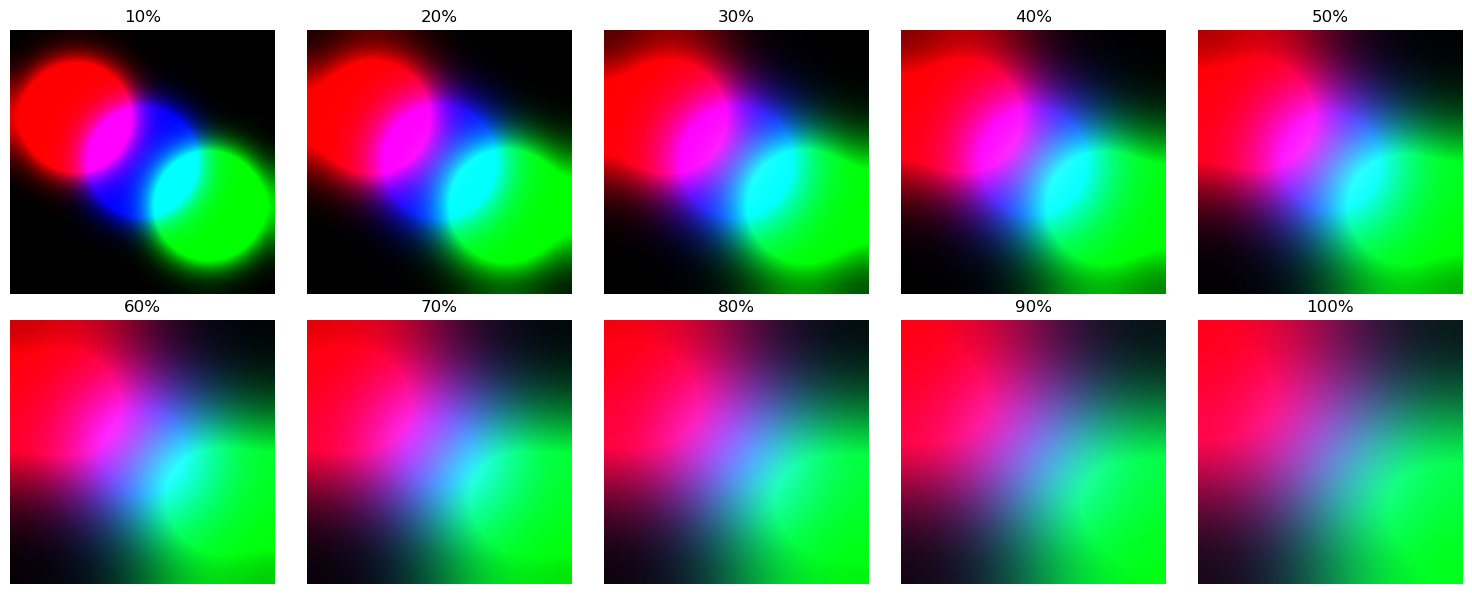

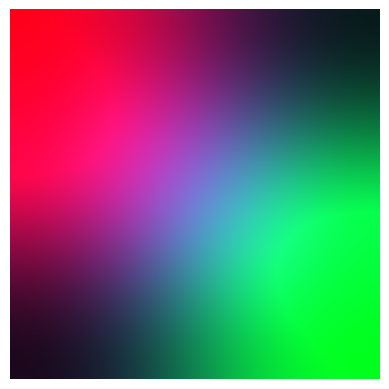

In [1]:
import os
import glob
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import math

# katalog z obrazami
frame_dir = "frames"
frame_paths = sorted(glob.glob(os.path.join(frame_dir, "frame_*.ppm")))

# policz pliki
num_frames = len(frame_paths)
print(f"Liczba znalezionych frame'ów: {num_frames}")

frames = []

# wczytaj obrazy
for fp in frame_paths:
    with Image.open(fp) as img:
        frames.append(img.copy())

# --- WYŚWIETLENIE PIERWSZEGO FRAME'A ---
print("Wyświetlam pierwszy frame...")
plt.figure(figsize=(5, 5))
plt.title("Frame 0")
plt.imshow(frames[0])
plt.axis('off')
plt.show()

# --- WYŚWIETLANIE FRAME'ÓW CO 10% ---
percent_frames = []

print("Wyświetlam frame'y co 10%:")

for p in range(10, 101, 10):
    idx = math.floor((p / 100) * (num_frames - 1))
    percent_frames.append((p, frames[idx]))

# rysowanie
cols = 5
rows = math.ceil(len(percent_frames) / cols)

plt.figure(figsize=(15, 6))

for i, (p, fr) in enumerate(percent_frames, 1):
    plt.subplot(rows, cols, i)
    plt.imshow(fr)
    plt.title(f"{p}%")
    plt.axis("off")

plt.tight_layout()
plt.show()

# --- ANIMACJA ---
fig = plt.figure()
plt.axis('off')
im = plt.imshow(frames[0])

def update(frame):
    im.set_data(frame)
    return [im]

ani = animation.FuncAnimation(fig, update, frames=frames, interval=50)

ani.save('flood_sim.gif', writer='pillow')

plt.show()
